<a href="https://www.kaggle.com/code/omborse771924/modern-flower-morphometrics-200k-eda?scriptVersionId=331619625" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jacopoferretti/iris-2-0-modern-flower-morphometrics-200k/extended_flower_morphometrics.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/jacopoferretti/iris-2-0-modern-flower-morphometrics-200k/extended_flower_morphometrics.csv')

In [3]:
df.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m,species
0,4.317614,3.028292,6.092543,3.166156,5.063025,63.558150,55.913100,886.568622,Rose
1,5.531122,3.887679,5.497682,2.374855,4.656235,52.368783,26.383116,247.206553,Iris Versicolor
2,5.908407,2.576321,6.264473,1.785481,5.893707,36.056153,61.562376,1197.921681,Orchid
3,6.855284,2.764075,4.606390,1.175031,4.854951,55.623467,38.671083,940.401196,Iris Versicolor
4,5.412124,3.691987,1.800383,0.221225,2.528513,60.218904,34.674831,679.473136,Iris Setosa


In [4]:
df.tail()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m,species
199995,4.310318,3.203669,4.608296,3.181966,6.685197,74.660851,57.874758,669.014693,Rose
199996,5.441338,2.540579,3.065710,3.081896,6.412263,36.600376,49.377932,410.593633,Rose
199997,7.634411,2.717171,5.527709,0.544835,7.115064,64.974656,55.590180,1141.716023,Orchid
199998,5.840849,1.975244,8.855018,2.062708,6.483508,54.200146,28.485977,921.509666,Orchid
199999,6.177141,3.201139,4.291363,2.253710,4.440774,72.793139,34.516120,1143.161113,Orchid


In [5]:
df.describe

<bound method NDFrame.describe of         sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
0              4.317614        3.028292         6.092543        3.166156   
1              5.531122        3.887679         5.497682        2.374855   
2              5.908407        2.576321         6.264473        1.785481   
3              6.855284        2.764075         4.606390        1.175031   
4              5.412124        3.691987         1.800383        0.221225   
...                 ...             ...              ...             ...   
199995         4.310318        3.203669         4.608296        3.181966   
199996         5.441338        2.540579         3.065710        3.081896   
199997         7.634411        2.717171         5.527709        0.544835   
199998         5.840849        1.975244         8.855018        2.062708   
199999         6.177141        3.201139         4.291363        2.253710   

        stem_thickness_mm  petal_density_pct  chlorop

In [6]:
df.isnull()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m,species
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
199995,False,False,False,False,False,False,False,False,False
199996,False,False,False,False,False,False,False,False,False
199997,False,False,False,False,False,False,False,False,False
199998,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

sepal_length_cm      0
sepal_width_cm       0
petal_length_cm      0
petal_width_cm       0
stem_thickness_mm    0
petal_density_pct    0
chlorophyll_index    0
native_altitude_m    0
species              0
dtype: int64

In [8]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
199995    False
199996    False
199997    False
199998    False
199999    False
Length: 200000, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm',
       'petal_width_cm', 'stem_thickness_mm', 'petal_density_pct',
       'chlorophyll_index', 'native_altitude_m', 'species'],
      dtype='object')

## EDA

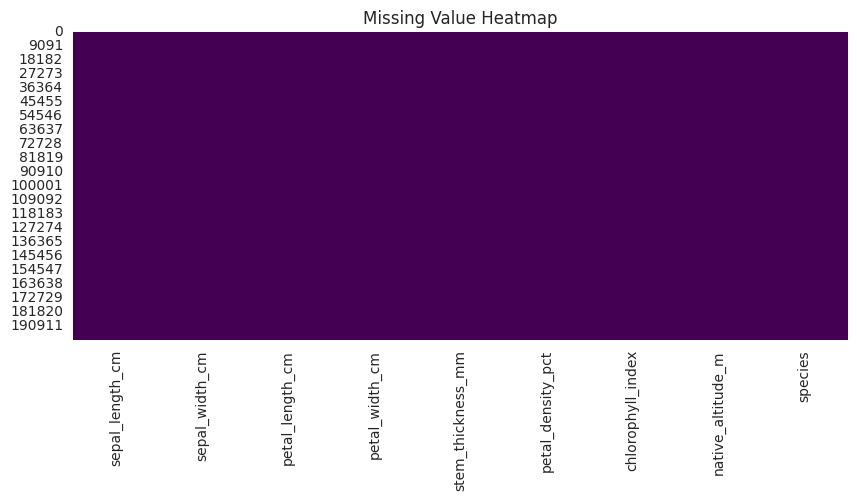

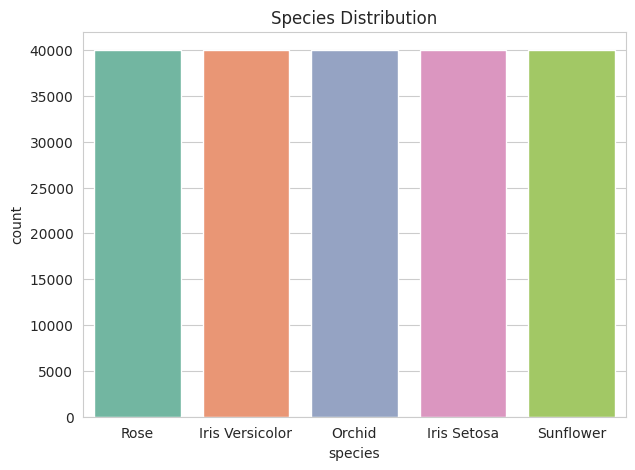

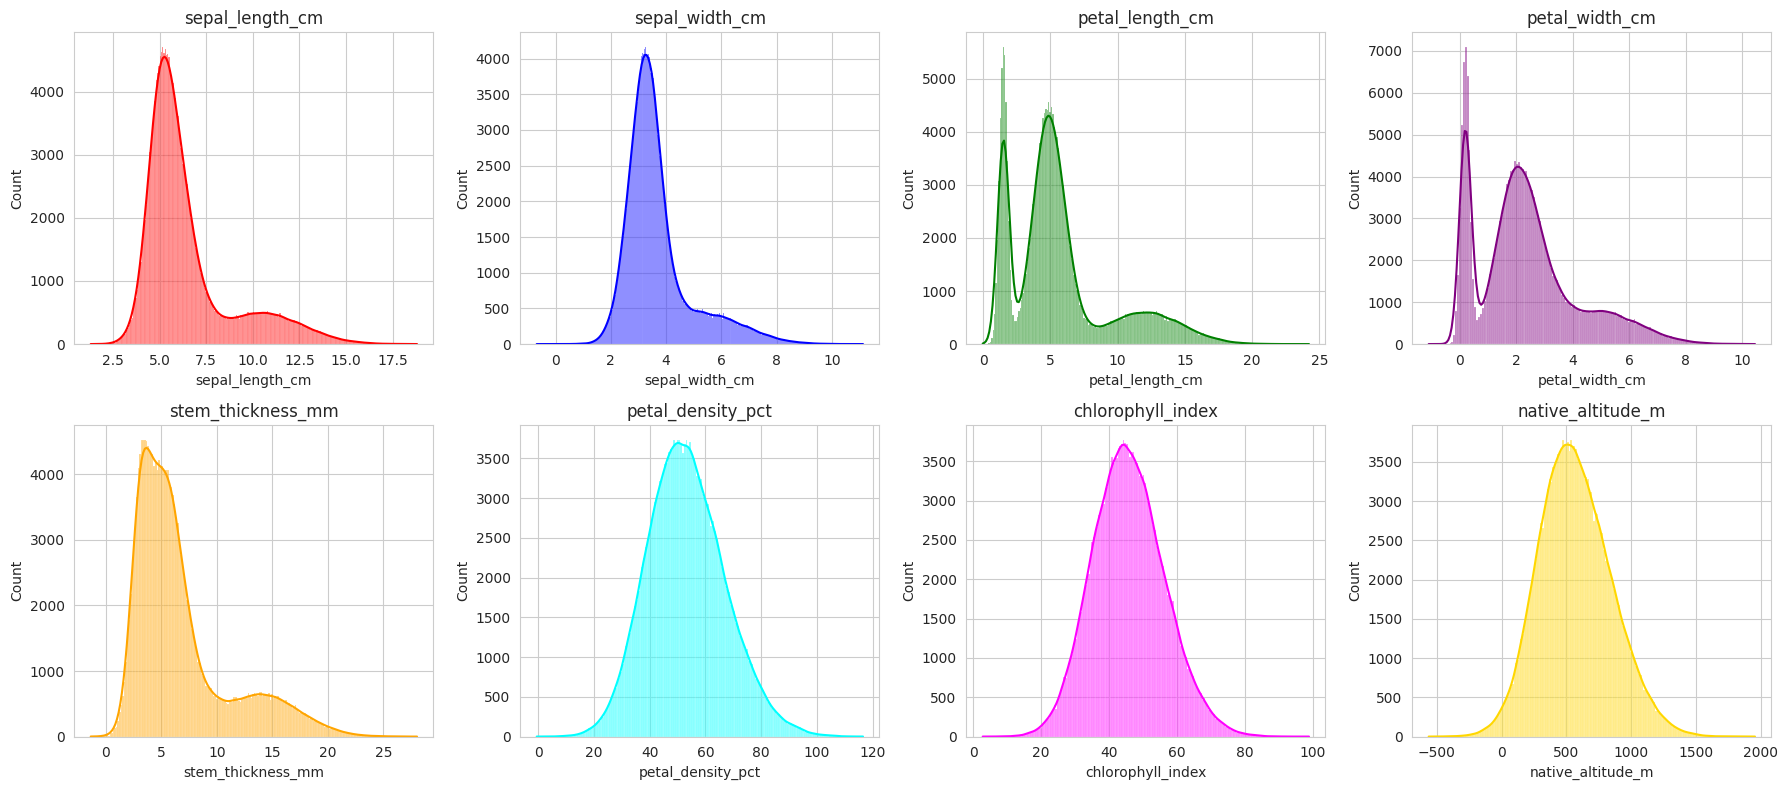

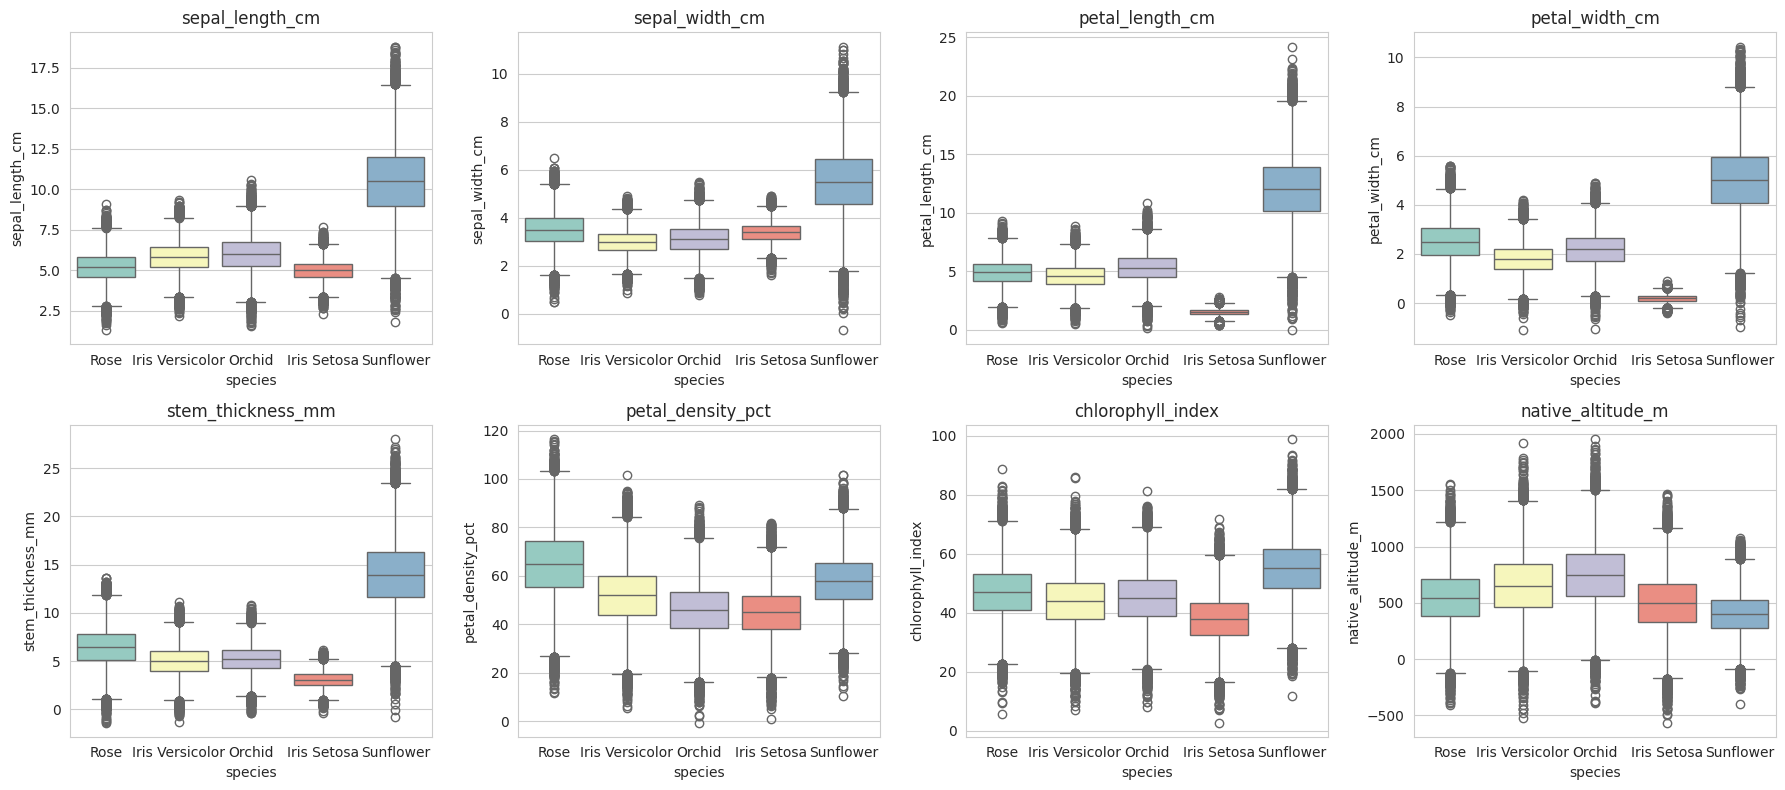

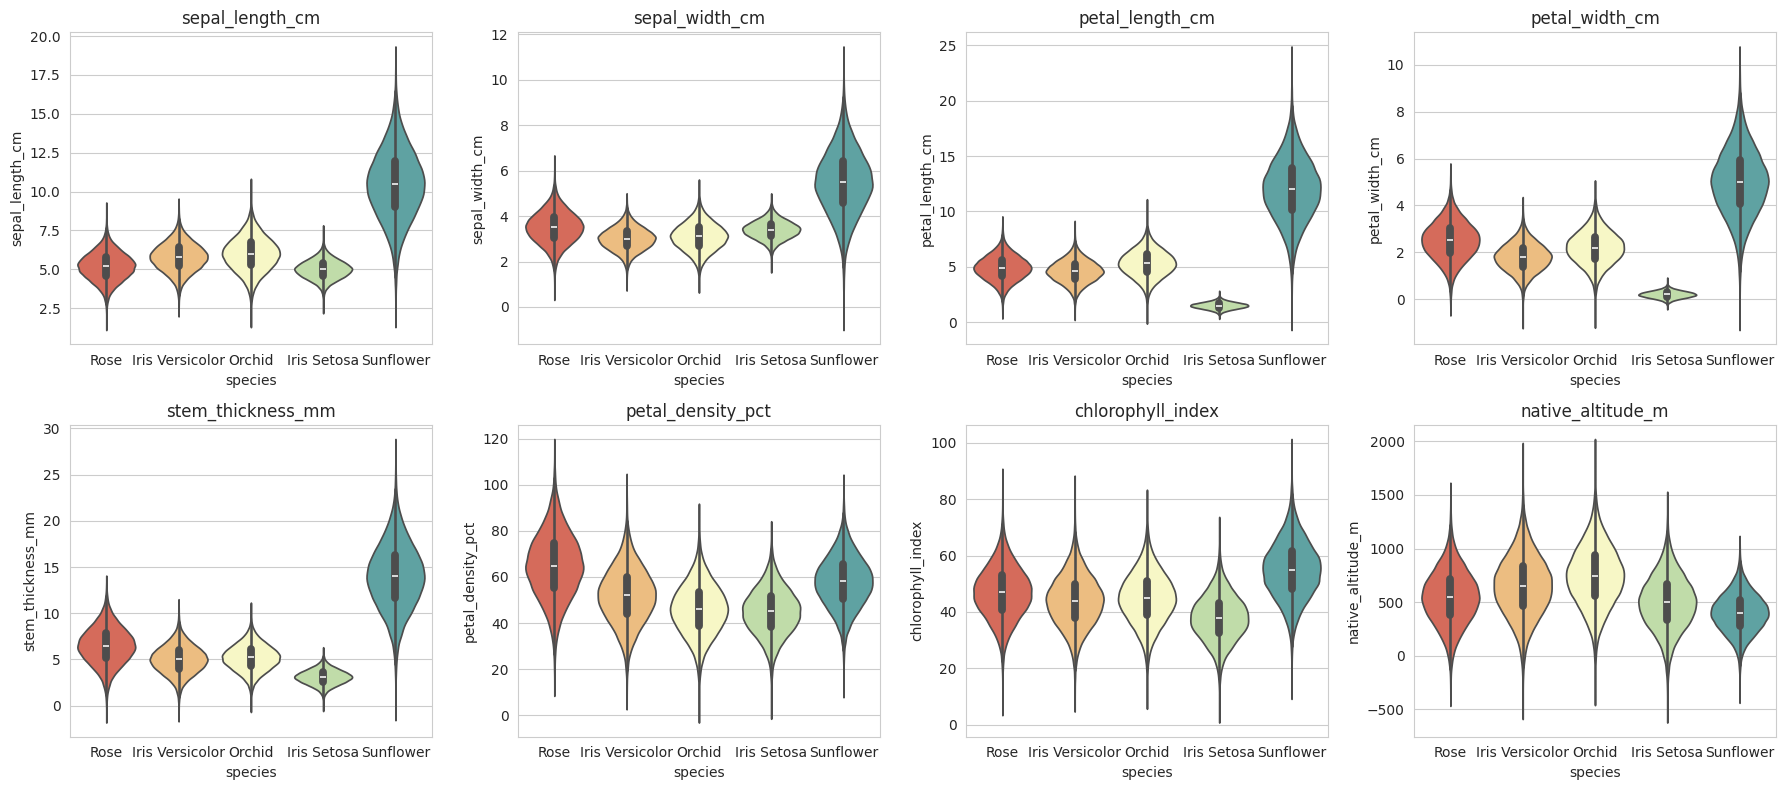

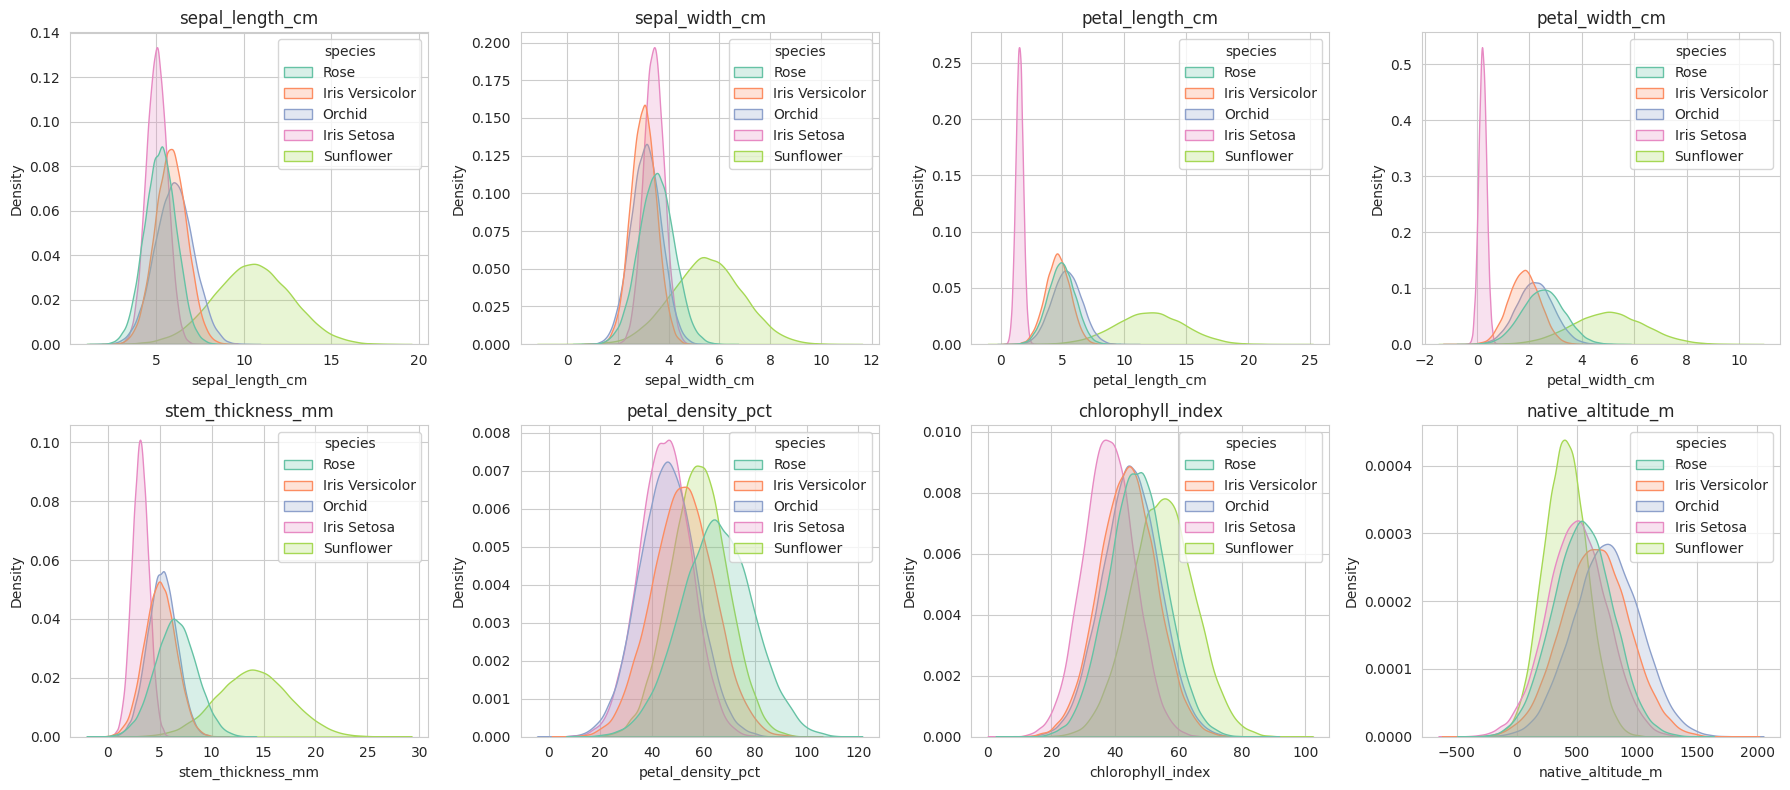

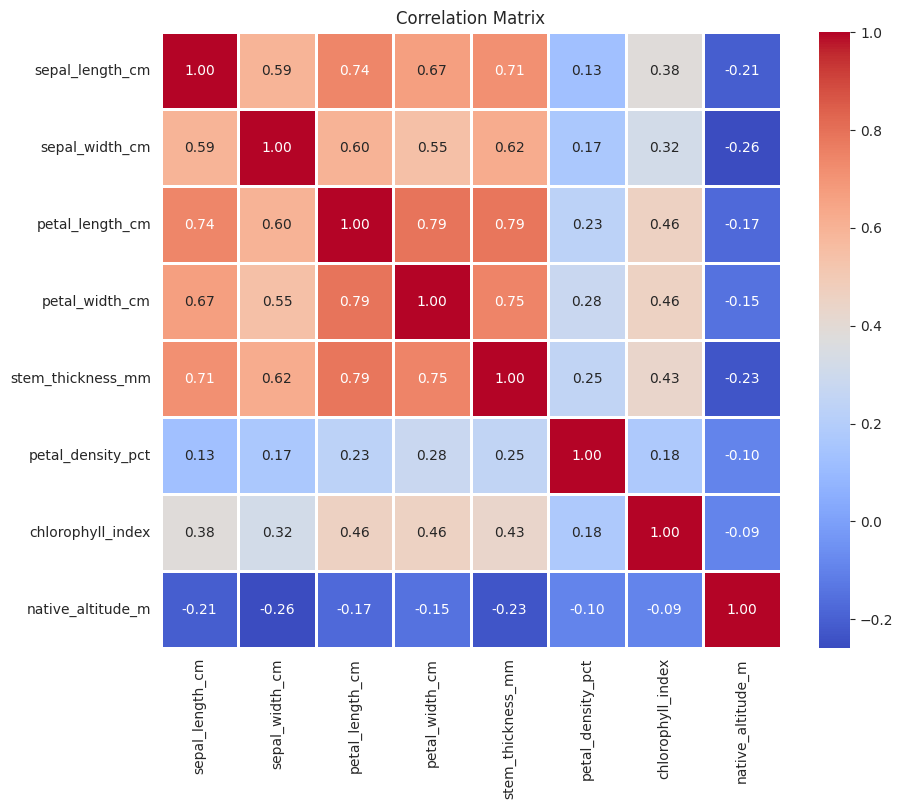

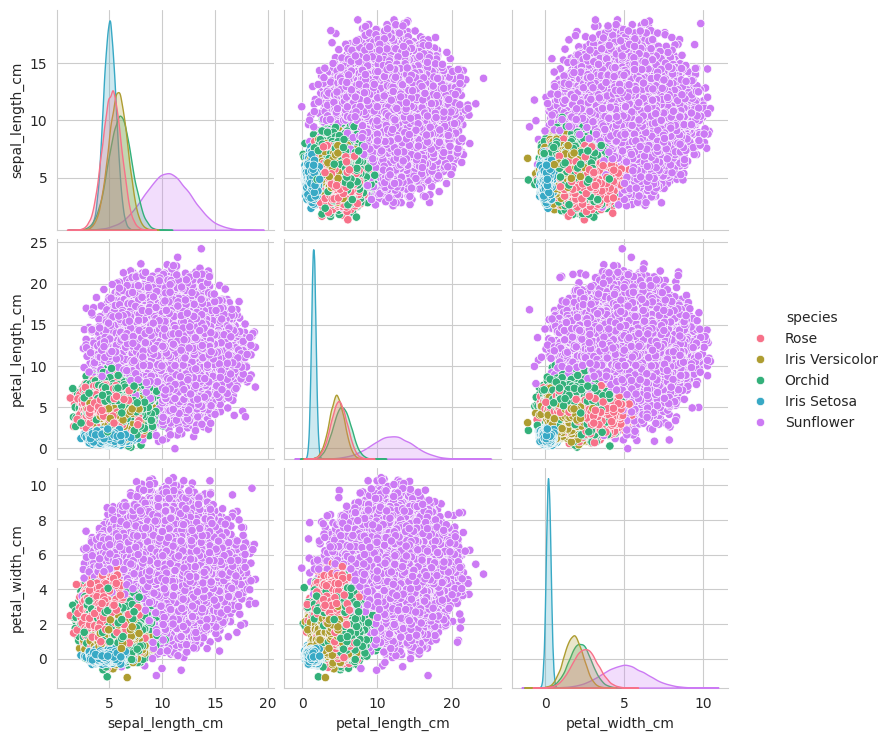

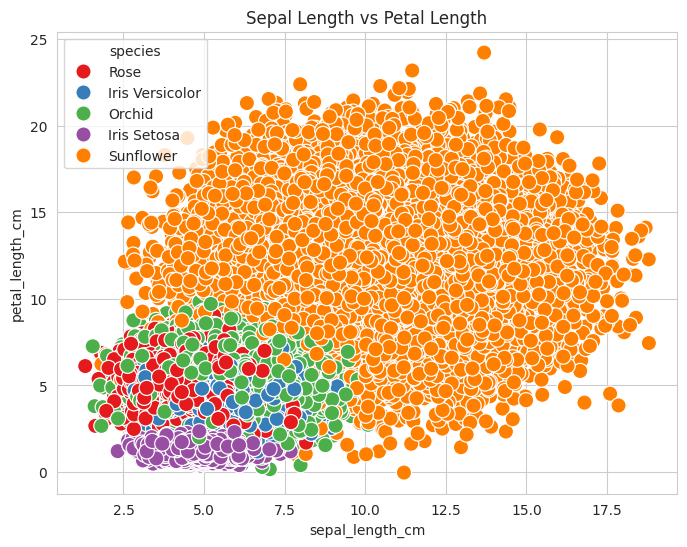

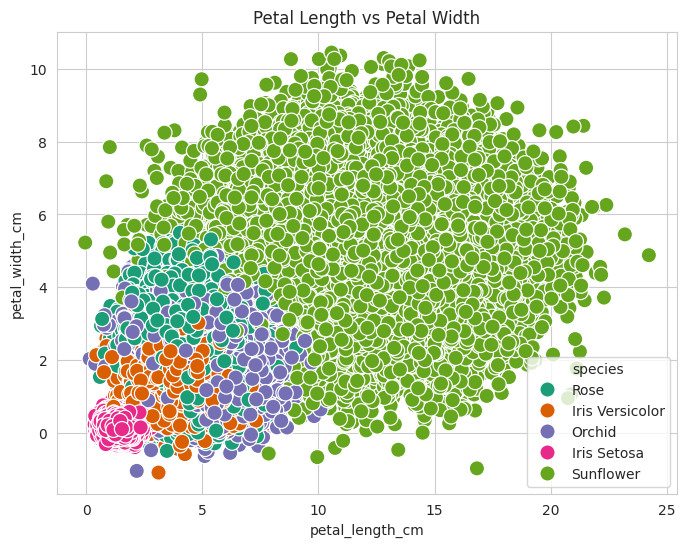

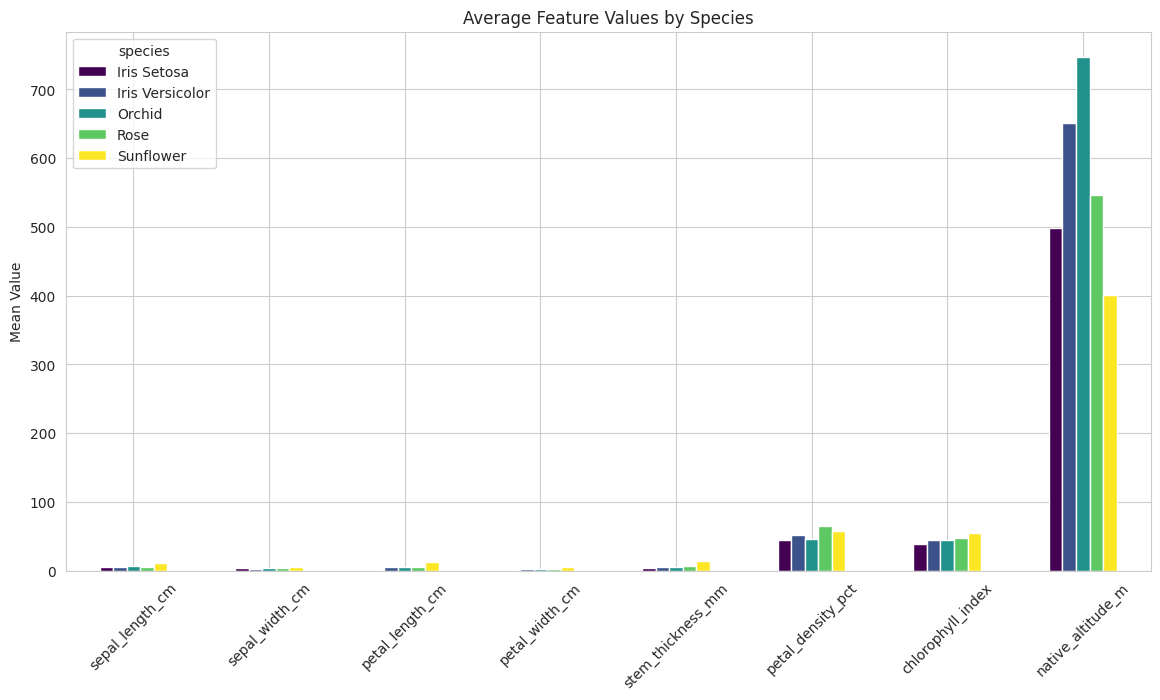

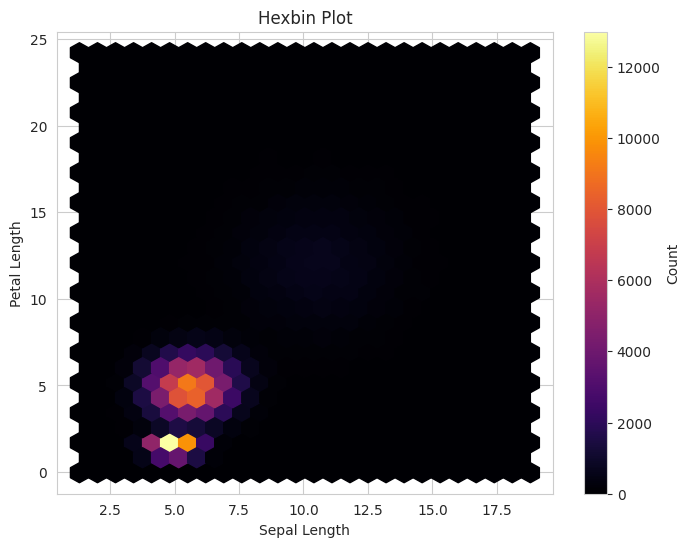

In [11]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

# Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns

# ============================================================
# 1. MISSING VALUE HEATMAP
# ============================================================

plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

# ============================================================
# 2. TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="species", palette="Set2")
plt.title("Species Distribution")
plt.show()

# ============================================================
# 3. HISTOGRAMS (ALL IN ONE FIGURE)
# ============================================================

fig, axes = plt.subplots(2,4, figsize=(18,8))

colors = ['red','blue','green','purple','orange','cyan','magenta','gold']

for ax, col, color in zip(axes.flat, num_cols, colors):
    sns.histplot(df[col], kde=True, color=color, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# ============================================================
# 4. BOXPLOTS (ALL IN ONE FIGURE)
# ============================================================

fig, axes = plt.subplots(2,4, figsize=(18,8))

for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x='species', y=col, palette="Set3", ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# ============================================================
# 5. VIOLIN PLOTS (ALL IN ONE FIGURE)
# ============================================================

fig, axes = plt.subplots(2,4, figsize=(18,8))

for ax, col in zip(axes.flat, num_cols):
    sns.violinplot(data=df, x='species', y=col, palette="Spectral", ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# ============================================================
# 6. KDE PLOTS (ALL IN ONE FIGURE)
# ============================================================

fig, axes = plt.subplots(2,4, figsize=(18,8))

for ax, col in zip(axes.flat, num_cols):
    sns.kdeplot(data=df, x=col, hue="species", fill=True,
                palette="Set2", ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# ============================================================
# 7. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=1)
plt.title("Correlation Matrix")
plt.show()

# ============================================================
# 8. PAIRPLOT
# (Only Important Columns)
# ============================================================

important_cols = [
    'sepal_length_cm',
    'petal_length_cm',
    'petal_width_cm',
    'species'
]

sns.pairplot(
    df[important_cols],
    hue="species",
    palette="husl",
    height=2.5
)

plt.show()

# ============================================================
# 9. SCATTER PLOT
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='sepal_length_cm',
    y='petal_length_cm',
    hue='species',
    palette='Set1',
    s=120
)

plt.title("Sepal Length vs Petal Length")
plt.show()

# ============================================================
# 10. SCATTER PLOT
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='petal_length_cm',
    y='petal_width_cm',
    hue='species',
    palette='Dark2',
    s=120
)

plt.title("Petal Length vs Petal Width")
plt.show()

# ============================================================
# 11. BARPLOT OF MEAN VALUES
# ============================================================

mean_df = df.groupby("species")[num_cols].mean().T

mean_df.plot(kind="bar",
             figsize=(14,7),
             colormap="viridis")

plt.title("Average Feature Values by Species")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# ============================================================
# 12. HEXBIN PLOT
# ============================================================

plt.figure(figsize=(8,6))

plt.hexbin(df["sepal_length_cm"],
           df["petal_length_cm"],
           gridsize=25,
           cmap="inferno")

plt.colorbar(label="Count")

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.title("Hexbin Plot")

plt.show()

## Features Engineering

Logistic Regression
Accuracy : 0.8117
Precision: 0.811
Recall   : 0.8117
F1 Score : 0.8114
                 precision    recall  f1-score   support

    Iris Setosa       1.00      1.00      1.00      8000
Iris Versicolor       0.62      0.61      0.62      8000
         Orchid       0.65      0.65      0.65      8000
           Rose       0.78      0.80      0.79      8000
      Sunflower       1.00      1.00      1.00      8000

       accuracy                           0.81     40000
      macro avg       0.81      0.81      0.81     40000
   weighted avg       0.81      0.81      0.81     40000

Decision Tree
Accuracy : 0.7537
Precision: 0.7543
Recall   : 0.7537
F1 Score : 0.754
                 precision    recall  f1-score   support

    Iris Setosa       1.00      1.00      1.00      8000
Iris Versicolor       0.52      0.53      0.52      8000
         Orchid       0.55      0.55      0.55      8000
           Rose       0.71      0.70      0.70      8000
      Sunflower       

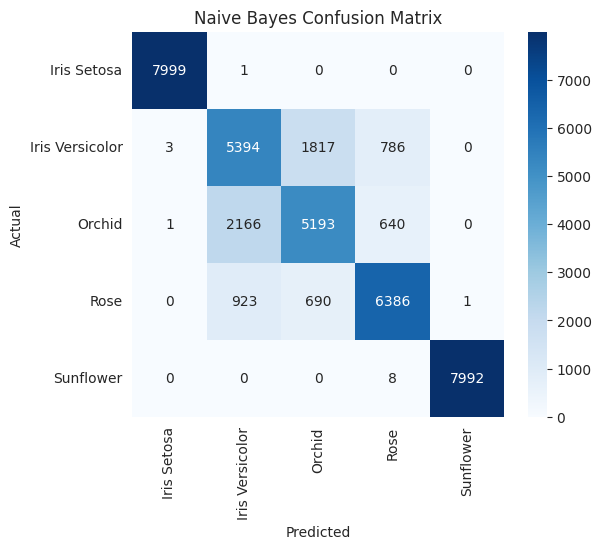

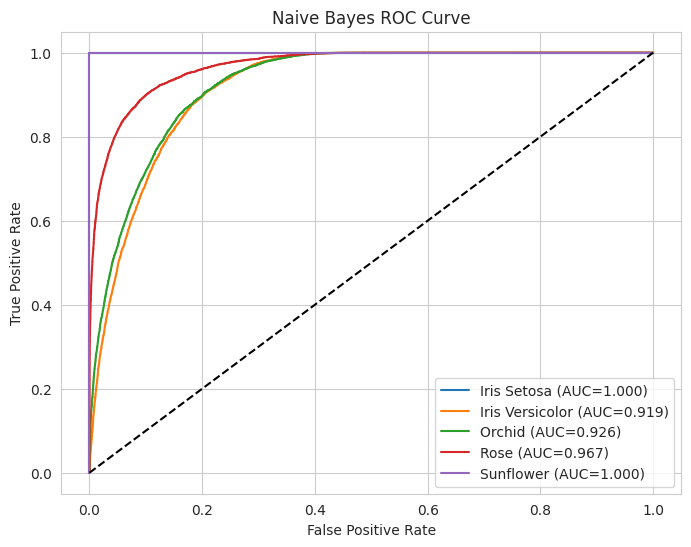

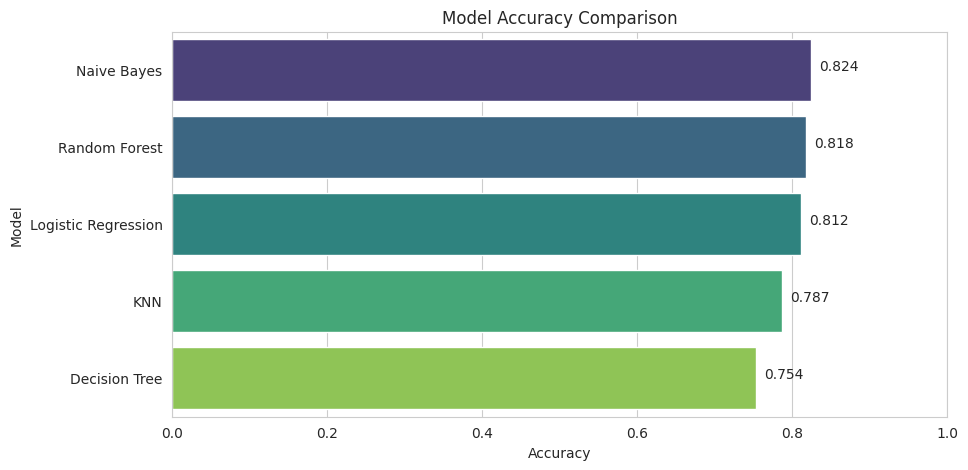

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# =====================================================
# FEATURES & TARGET
# =====================================================

X = df.drop("species", axis=1)
y = df["species"]

# =====================================================
# LABEL ENCODING
# =====================================================

le = LabelEncoder()
y = le.fit_transform(y)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# FEATURE SCALING
# =====================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =====================================================
# MODELS
# =====================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes": GaussianNB()
}

results = []

classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# =====================================================
# TRAINING
# =====================================================

for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy :", round(acc,4))
    print("Precision:", round(pre,4))
    print("Recall   :", round(rec,4))
    print("F1 Score :", round(f1,4))

    print(classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    ))

    results.append([name, acc, pre, rec, f1])

# =====================================================
# RESULT TABLE
# =====================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

# =====================================================
# BEST MODEL
# =====================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

# =====================================================
# CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test,y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title(best_model_name + " Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# ROC CURVE
# =====================================================

y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr,tpr,_ = roc_curve(
        y_test_bin[:,i],
        y_score[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{le.classes_[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(best_model_name + " ROC Curve")
plt.legend()

plt.show()

# =====================================================
# ACCURACY COMPARISON
# =====================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

for i,v in enumerate(results_df["Accuracy"]):
    plt.text(v+0.01,i,f"{v:.3f}")

plt.xlim(0,1)

plt.show()

## Thanks......Please Upvote